# 02 LILAC SH5 Training

Notebook entrypoint for canonical language indexing, training-array preparation, and LILAC model training.

In [1]:
%run ../package/init_project.py

import json
import matplotlib.pyplot as plt
import numpy as np

from language import CanonicalLanguageDataset, CanonicalLanguageIndex, TransformerLanguageEmbedder
from paths import CACHE_DIR, CANONICAL_LANGUAGE_DATASET, CANONICAL_LANGUAGE_INDEX, DATA_DIR, RUN_DIR, TRAINING_ARRAYS



[LILAC_project] initialized.


In [2]:
# Paper-style multitask training: use every trajectory under data/<task>/instruction and data/<task>/correction.
EPISODE_TYPES = ["instruction", "correction"]
PAPER_TRAIN_EPOCHS = 60

DATASET_DIRS = resolve_all_dataset_dirs(DATA_DIR, episode_types=EPISODE_TYPES)
episode_npzs = []
for dataset_dir in DATASET_DIRS:
    episode_npzs.extend(sorted(dataset_dir.glob("*.npz")))
if not episode_npzs:
    raise FileNotFoundError("No .npz episodes found under data/.")

print("Datasets:")
for dataset_dir in DATASET_DIRS:
    print(" -", dataset_dir.relative_to(DATA_DIR))
print("Episodes:", len(episode_npzs))
print("Arrays:", TRAINING_ARRAYS)
print("Run dir:", RUN_DIR)
print("Training defaults: epochs=%d, batch_size=512, optimizer=AdamW" % PAPER_TRAIN_EPOCHS)


Datasets:
 - cup_to_bowl/correction
 - cup_to_bowl/instruction
 - remote_controller_to_box/instruction
Episodes: 97
Arrays: /Users/junha/workspace/RILAB/lab_semina/project/LILAC_project/data/training/lilac_sh5_right_arrays.npz
Run dir: /Users/junha/workspace/RILAB/lab_semina/project/LILAC_project/runs/lilac_sh5_right
Training defaults: epochs=60, batch_size=512, optimizer=AdamW


In [3]:
# Canonical language dataset
language_dataset = CanonicalLanguageDataset.load(CANONICAL_LANGUAGE_DATASET)

print("Canonical utterances:")
for entry in language_dataset.entries:
    print(" - %-18s kind=%-11s alpha=%.1f text=%s" % (
        entry.id,
        entry.kind,
        entry.alpha,
        entry.text,
    ))


Canonical utterances:
 - pick_up_cup_pour_into_bowl kind=instruction alpha=1.0 text=Pick up the cup and pour water into the bowl.
 - pick_up_remote_put_in_box kind=instruction alpha=1.0 text=pick up remote controller put in box
 - right              kind=correction  alpha=0.0 text=right
 - pour_water         kind=correction  alpha=0.0 text=pour water
 - left               kind=correction  alpha=0.0 text=left
 - down               kind=correction  alpha=0.0 text=down
 - up                 kind=correction  alpha=0.0 text=up
 - front              kind=correction  alpha=0.0 text=front
 - back               kind=correction  alpha=0.0 text=back


In [4]:
# Load canonical SBERT embeddings, or rebuild them if the language table changed.
language_index = None
if CANONICAL_LANGUAGE_INDEX.exists():
    loaded_language_index = CanonicalLanguageIndex.load(CANONICAL_LANGUAGE_INDEX)
    if (
        loaded_language_index.ids == language_dataset.ids()
        and loaded_language_index.utterances == language_dataset.texts()
    ):
        language_index = loaded_language_index
        print("Loaded language index:", CANONICAL_LANGUAGE_INDEX)
    else:
        print("Language index is stale; rebuilding:", CANONICAL_LANGUAGE_INDEX)

if language_index is None:
    embedder = TransformerLanguageEmbedder(
        model_name = "sentence-transformers/paraphrase-xlm-r-multilingual-v1",
        cache_dir  = str(CACHE_DIR / "sbert"),
        device     = "cpu",
    )
    language_index = CanonicalLanguageIndex.build(
        dataset  = language_dataset,
        embedder = embedder,
    )
    language_index.save(CANONICAL_LANGUAGE_INDEX)
    print("Saved language index:", CANONICAL_LANGUAGE_INDEX)

print("Embedding shape:", language_index.embeddings.shape)


Loaded language index: /Users/junha/workspace/RILAB/lab_semina/project/LILAC_project/data/language/language_index.npz
Embedding shape: (9, 768)


In [5]:
# Build training arrays from every trajectory dataset under data/.
arrays_path = prepare_training_arrays(
    data_dir              = DATA_DIR,
    out_path              = TRAINING_ARRAYS,
    tasks                 = None,
    episode_types         = EPISODE_TYPES,
    language_dataset_path = CANONICAL_LANGUAGE_DATASET,
    normalize_actions     = True,
)
print("Saved training arrays:", arrays_path)

arrays = np.load(arrays_path, allow_pickle=True)
states = np.asarray(arrays["states"])
actions = np.asarray(arrays["actions"])
utterances = np.asarray(arrays["utterances"], dtype=object)
alphas = np.asarray(arrays["alphas"])

print("states:", states.shape)
print("actions:", actions.shape)
print("utterances:", sorted(set(str(u) for u in utterances.tolist())))
print("alpha values:", sorted(set(float(a) for a in alphas.tolist())))


Saved training arrays: /Users/junha/workspace/RILAB/lab_semina/project/LILAC_project/data/training/lilac_sh5_right_arrays.npz
states: (17930, 19)
actions: (17930, 6)
utterances: ['Pick up the cup and pour water into the bowl.', 'back', 'down', 'front', 'left', 'pick up remote controller put in box', 'pour water', 'right', 'up']
alpha values: [0.0, 1.0]


In [6]:
# Train one multitask LILAC model. The fixed run directory is overwritten after a successful train.
run_dir = RUN_DIR
print("Run dir:", run_dir)

result = train_lilac_from_arrays(
    arrays_path           = arrays_path,
    run_dir               = run_dir,
    language_index_path   = CANONICAL_LANGUAGE_INDEX,
    language_dataset_path = CANONICAL_LANGUAGE_DATASET,
    n_epochs              = PAPER_TRAIN_EPOCHS,
    overwrite_run         = True,
    prune_existing_runs   = True,
)
run_dir = result["run_dir"]
print("Saved run:", run_dir)
print("Removed old runs:", [str(path) for path in result.get("removed_run_dirs", [])])


Run dir: /Users/junha/workspace/RILAB/lab_semina/project/LILAC_project/runs/lilac_sh5_right
[epoch 000] train_loss=0.135976 val_loss=0.095640
[epoch 001] train_loss=0.071972 val_loss=0.052179
[epoch 002] train_loss=0.048576 val_loss=0.042706
[epoch 003] train_loss=0.043084 val_loss=0.039471
[epoch 004] train_loss=0.040207 val_loss=0.036690
[epoch 005] train_loss=0.038625 val_loss=0.035445
[epoch 006] train_loss=0.036798 val_loss=0.033824
[epoch 007] train_loss=0.035844 val_loss=0.032590
[epoch 008] train_loss=0.034496 val_loss=0.032239
[epoch 009] train_loss=0.033093 val_loss=0.031022
[epoch 010] train_loss=0.032156 val_loss=0.030083
[epoch 011] train_loss=0.030203 val_loss=0.028149
[epoch 012] train_loss=0.028688 val_loss=0.026647
[epoch 013] train_loss=0.027261 val_loss=0.025392
[epoch 014] train_loss=0.026156 val_loss=0.025026
[epoch 015] train_loss=0.025132 val_loss=0.023743
[epoch 016] train_loss=0.024447 val_loss=0.022981
[epoch 017] train_loss=0.023333 val_loss=0.022078
[epoch 0

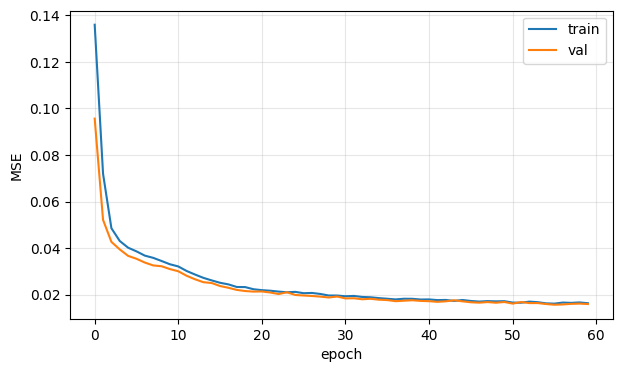

Final train loss: 0.016356574546080083
Final val loss: 0.01600780850276351


: 

In [ ]:
# Inspect training history
history_path = run_dir / "history.json"
if history_path.exists():
    history = json.loads(history_path.read_text())
    epochs = [row["epoch"] for row in history]
    train_loss = [row["train_loss"] for row in history]
    val_loss = [np.nan if row["val_loss"] is None else row["val_loss"] for row in history]

    plt.figure(figsize=(7, 4))
    plt.plot(epochs, train_loss, label="train")
    if not np.all(np.isnan(val_loss)):
        plt.plot(epochs, val_loss, label="val")
    plt.xlabel("epoch")
    plt.ylabel("MSE")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.show()

    print("Final train loss:", train_loss[-1])
    if not np.isnan(val_loss[-1]):
        print("Final val loss:", val_loss[-1])
else:
    print("No history found:", history_path)
